found path at /workspace/Foundations/lib/algorithms/PCA.py
added path


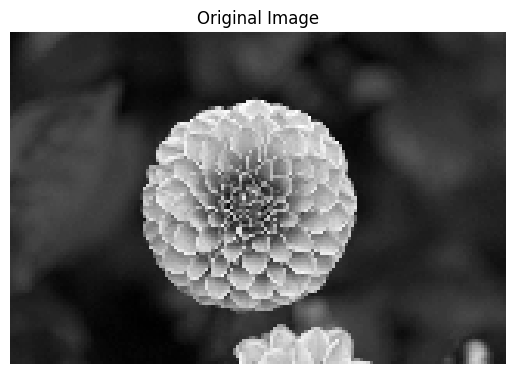

Image shape: (107, 160)
Pixel values range: 3 to 211
Original size: 17120
Original size: 17120
Components shape: (10, 160)
Transformed shape: (107, 10)
Components storage: 1600
Coefficients storage: 1070
Compressed size: 2670
Ratio: 6.411985018726591


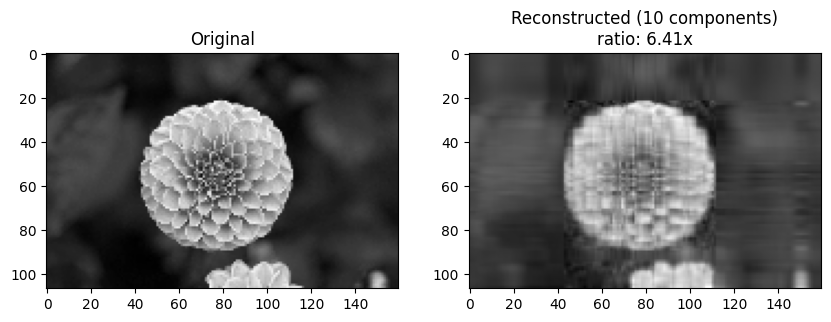

Original size: 17120
Original size: 17120
Components shape: (1, 160)
Transformed shape: (107, 1)
Components storage: 160
Coefficients storage: 107
Compressed size: 267
Ratio: 64.11985018726591


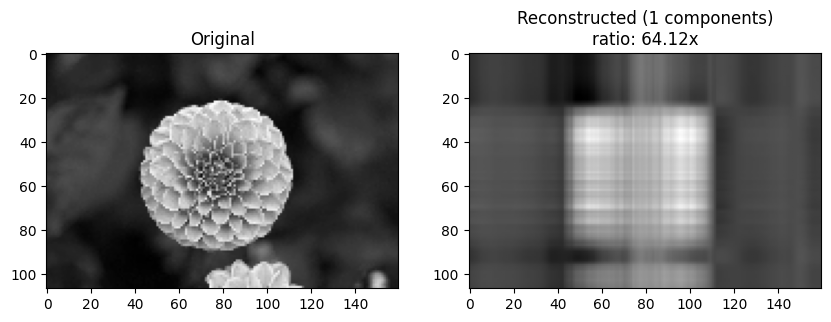

Original size: 17120
Original size: 17120
Components shape: (50, 160)
Transformed shape: (107, 50)
Components storage: 8000
Coefficients storage: 5350
Compressed size: 13350
Ratio: 1.2823970037453183


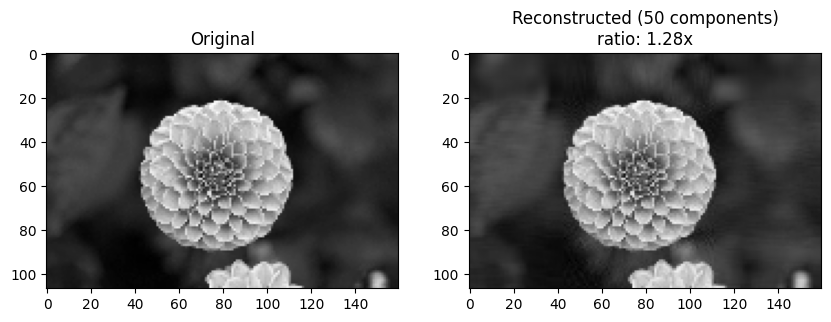

Original size: 17120
Original size: 17120
Components shape: (100, 160)
Transformed shape: (107, 100)
Components storage: 16000
Coefficients storage: 10700
Compressed size: 26700
Ratio: 0.6411985018726591


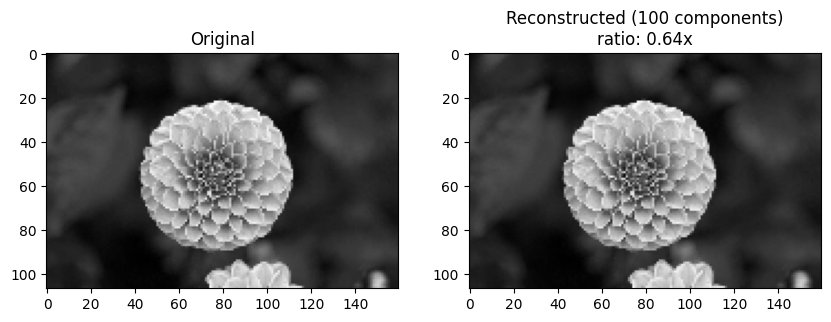

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import os
import sys
from sklearn.datasets import load_sample_image
#print(f"Current Working Directory: {os.getcwd()}")
potential_paths = [
    '../lib/algorithms',
    'lib/algorithms',
    'Foundations/lib/algorithms',
    './lib/algorithms'
]
pca_path_found = False
for p in potential_paths:
    check_path = os.path.abspath(p)
    if os.path.exists(os.path.join(check_path, 'PCA.py')):
        if check_path not in sys.path:
            sys.path.append(check_path)
        print(f"found path at {os.path.join(check_path, 'PCA.py')}")
        print("added path")
        pca_path_found = True
if not pca_path_found:
    print("could not find pca")
else:
    from PCA import PCA

### USING SKLEARN ONLY TO GET AN IMAGE.

def load_sample_image_simple() -> np.ndarray:
    """
    Load a sample grayscale image for compression experiments.

    Returns:
        2D numpy array of shape (height, width) with pixel values
    """
    img = load_sample_image('flower.jpg')
    img_gray = img.mean(axis=2)
    img_small = img_gray[::4, ::4]

    return img_small.astype(np.uint8)
    
def compress_image_pca(image: np.ndarray, n_components: int) -> Tuple[np.ndarray, float, 'PCA']:
    """
    Compress a single image using PCA

    Strategy: Treat each row of the image as a data point, each column
    as a feature. Find principal components across rows.

    Args:
        image: 2D array of shape (height, width)
        n_components: Number of principal components to keep

    Returns:
        reconstruced: reconstructed image
        compression_ratio: Original size / compressed size
        pca: Fitted PCA object

    How it works:
    1. Each row of the image is a 1D vector of pixel values
    2. We have 'height' such vectors, each with 'width' features
    3. PCA finds patterns across these row vectors
    4. We keep only top n_components patterns
    5. Reconstruct the image from these components

    Compression ratio calculation:
    - Original: height * width values
    - Compressed: n_components * width (components) +
                  n_components * height (coefficients)
    """
    image_pca = PCA(n_components)
    transformed_image = image_pca.fit_transform(image)
    reconstructed_image = image_pca.inverse_transform(transformed_image)
    original_size = image.shape[0] * image.shape[1]
    compressed_size = (image_pca.components_.shape[0] * image_pca.components_.shape[1]) + \
    (transformed_image.shape[0] * transformed_image.shape[1]) 
    compression_ratio = original_size / compressed_size
    print(f"Original size: {original_size}")
    print(f"Original size: {original_size}")
    print(f"Components shape: {image_pca.components_.shape}")
    print(f"Transformed shape: {transformed_image.shape}")
    print(f"Components storage: {image_pca.components_.shape[0] * image_pca.components_.shape[1]}")
    print(f"Coefficients storage: {transformed_image.shape[0] * transformed_image.shape[1]}")
    print(f"Compressed size: {compressed_size}")
    print(f"Ratio: {compression_ratio}")
    return (reconstructed_image, compression_ratio, image_pca)
            
    

#Load and Visualize
original_image = load_sample_image_simple()
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

print(f"Image shape: {original_image.shape}")
print(f"Pixel values range: {original_image.min()} to {original_image.max()}")

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=10)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (10 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=1)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (1 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=50)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (50 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=100)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (100 components)\nratio: {ratio:.2f}x')
plt.show()

    

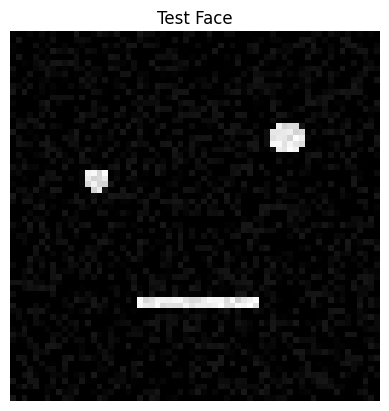

0.7983504842434442


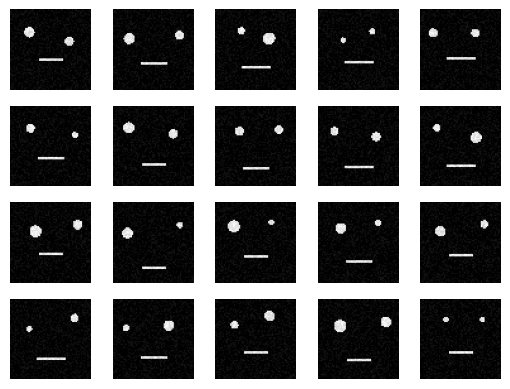

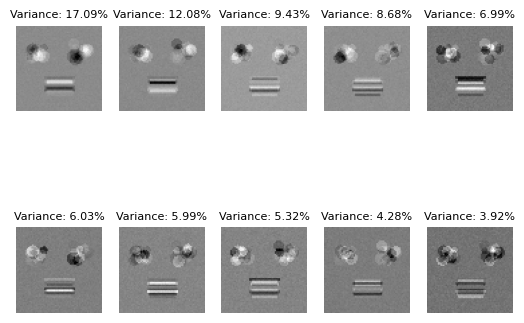

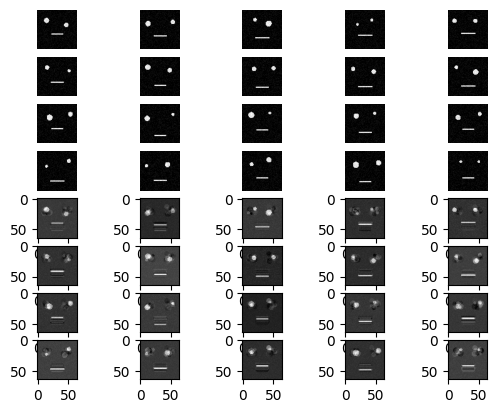

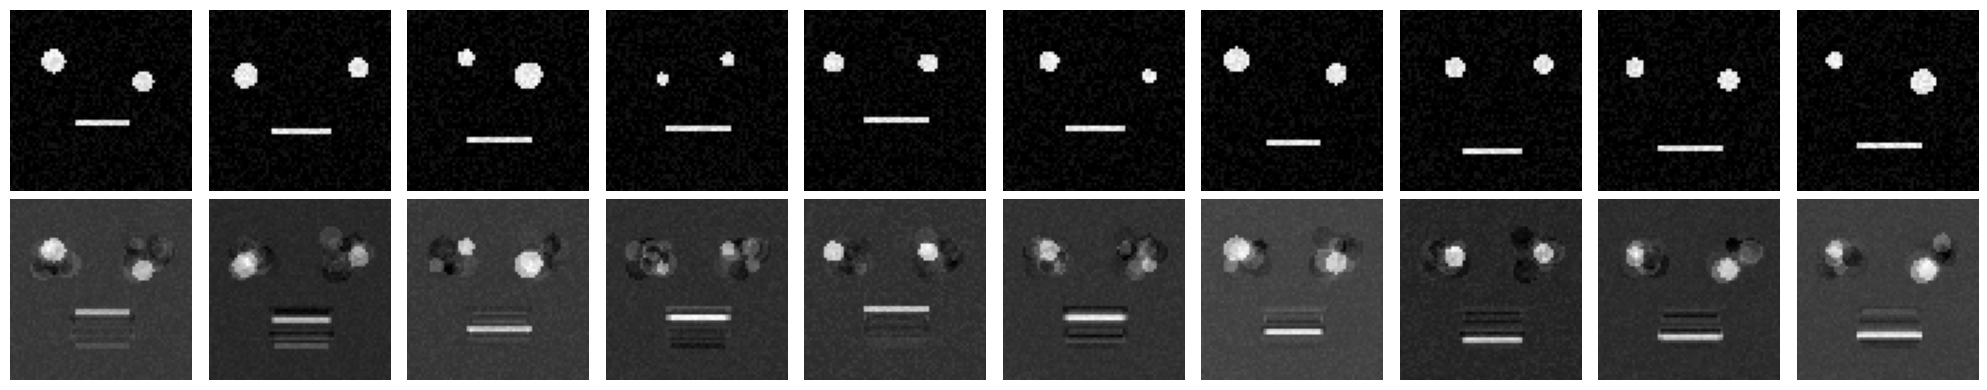

In [2]:
def generate_face(image_size: Tuple[int,int] = (64, 64)) -> np.ndarray:
    face = np.zeros((image_size))
    x_coords = np.arange(0, image_size[0])
    y_coords = np.arange(0, image_size[1])
    xx, yy = np.meshgrid(x_coords, y_coords)
    image_center = image_size[0] / 2

    left_eye_cx = np.random.uniform(image_size[0] * .15, image_size[0] *.35)
    left_eye_cy = np.random.uniform(image_size[1] * .2, image_size[1]*.4)
    left_eye_rad = np.random.uniform(2,5)
    left_eye_mask = (((xx-left_eye_cx)**2 + (yy-left_eye_cy)**2) < left_eye_rad**2)
    face[left_eye_mask] = .8


    right_eye_cx = np.random.uniform(image_size[0] * .65, image_size[0] * .85)
    right_eye_cy = np.random.uniform(image_size[1] * .2, image_size[1] * .4)
    right_eye_rad = np.random.uniform(2,5)
    right_eye_mask = (((xx-right_eye_cx)**2 + (yy-right_eye_cy)**2) < right_eye_rad**2)
    face[right_eye_mask] = .8

    mouth_y = np.random.uniform(image_size[1] *.6, image_size[1]*.8)
    mouth_width = np.random.uniform(18,24)
    mouth_thickness = 2
    left_edge, right_edge = image_center - mouth_width / 2, image_center + mouth_width / 2
    mouth_mask = ((xx <= right_edge) & (xx >= left_edge)) & \
    ((yy<= (mouth_y + mouth_thickness/2)) & (yy >= (mouth_y - mouth_thickness/2)))
    face[mouth_mask] = .8

    noise = np.random.uniform(-.08, .08, image_size)
    face = np.clip((face+noise), 0.0, 1.0)

    return face




def generate_synthetic_faces(n_faces: int=20, image_size: Tuple[int,int] = (64,64)) -> np.ndarray:
    """
    Generate synthetic 'face' images for demonstration.

    In practice, you would use a real face dataset:
    - ATT Face DB
    - Yale Face DB
    - LFW

    Args:
        n_faces: Number of face images to generate
        image_size: (height,width) of each face image

    Returns:
        Array of shape (n_faces, height, width)

    What this generates:
    - Simple face-like images witth:
        - two circular eyes in upper third
        - horizontal line mouth in lower third
        - Random noise for variation between faces
    """
    faces = np.zeros((n_faces, image_size[0], image_size[1]))
    for i in range(n_faces):
        face = generate_face(image_size=image_size)
        faces[i] = face
    return faces
    


test_face = generate_face()
plt.imshow(test_face, cmap='gray')
plt.axis('off')
plt.title("Test Face")
plt.show()

n_faces = 20
faces = generate_synthetic_faces(n_faces)
fig, axes = plt.subplots(4,5)
for i in range(n_faces):
    pos = axes.flatten()[i]
    pos.imshow(faces[i], cmap='gray')
    pos.axis('off')

flat_faces = faces.reshape(n_faces, -1)
n_eigenfaces = 10
pca = PCA(n_components=n_eigenfaces)
face_pca = pca.fit_transform(flat_faces)
reconstructed_faces = pca.inverse_transform(face_pca)
fig, axes = plt.subplots(2,5)
for i in range(n_eigenfaces):
    eigenface = pca.components_[i]
    eigenface_2d = eigenface.reshape(64,64)
    pos = axes.flatten()[i]
    pos.imshow(eigenface_2d, cmap='gray')
    pos.set_title(f'Variance: {pca.explained_variance_ratio_[i]:.2%}', fontsize=8)
    pos.axis('off')
total_variance = pca.explained_variance_ratio_.sum()
print(total_variance)

fig,axes = plt.subplots(8,5)
flattened_axes = axes.flatten()
for i in range(n_faces):
    flattened_axes[i].axis('off')
    original_face = flat_faces[i].reshape(64,64)
    reconstructed_face = reconstructed_faces[i].reshape(64,64)
    flattened_axes[i].imshow(original_face, cmap='gray')
    flattened_axes[i+20].imshow(reconstructed_face, cmap='gray')

fig,axes = plt.subplots(2,10, figsize=(20,4))
plt.subplots_adjust(0.02,0.02)
for i in range(10):
    original_face = flat_faces[i].reshape(64,64)
    reconstructed_face = reconstructed_faces[i].reshape(64,64)
    axes[0][i].axis('off')
    axes[0][i].imshow(original_face, cmap='gray')
    axes[1][i].axis('off')
    axes[1][i].imshow(reconstructed_face, cmap='gray')
plt.tight_layout()

    


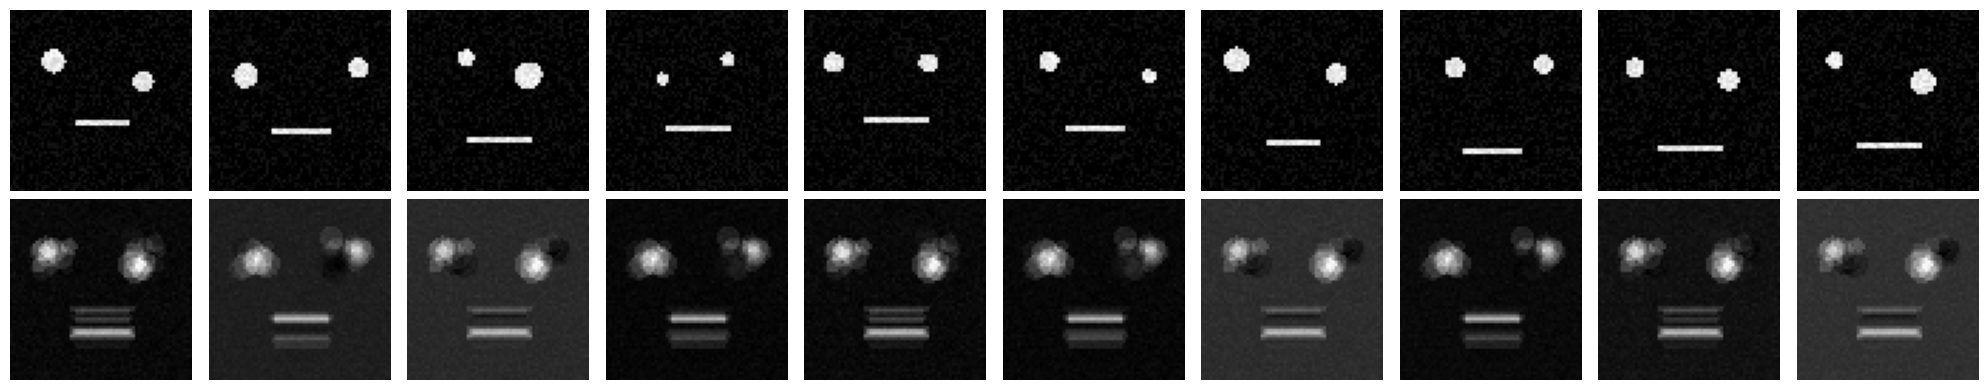

In [3]:
pca_1 = PCA(n_components=1)
face_pca = pca_1.fit_transform(flat_faces)
reconstructed_faces = pca_1.inverse_transform(face_pca)
fig,axes = plt.subplots(2,10, figsize=(20,4))
plt.subplots_adjust(0.02,0.02)
for i in range(10):
    original_face = flat_faces[i].reshape(64,64)
    reconstructed_face = reconstructed_faces[i].reshape(64,64)
    axes[0][i].axis('off')
    axes[0][i].imshow(original_face, cmap='gray')
    axes[1][i].axis('off')
    axes[1][i].imshow(reconstructed_face, cmap='gray')
plt.tight_layout()



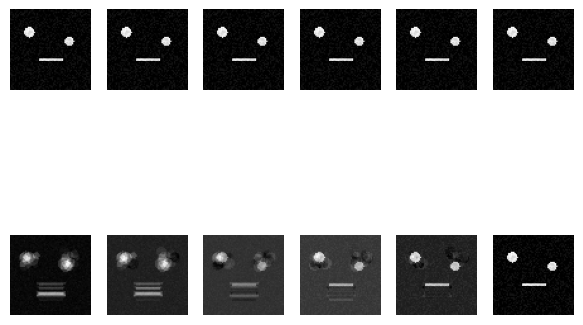

In [4]:
n_components_list = [1,2,5,10,15,20]
comparison = flat_faces[0].reshape(64,64)
reconstructions = []
for n_comp in n_components_list:
    pca = PCA(n_comp)
    face_pca = pca.fit_transform(flat_faces)
    reconstructed_faces = pca.inverse_transform(face_pca)
    reconstructed_face = reconstructed_faces[0].reshape(64,64)
    reconstructions.append(reconstructed_face)
fig, axes = plt.subplots(2,6)
plt.subplots_adjust(0.02,0.02)
for i,face in enumerate(reconstructions):
    axes[0][i].axis('off')
    axes[0][i].imshow(comparison, cmap='gray')
    axes[1][i].axis('off')
    axes[1][i].imshow(face, cmap='gray')

    


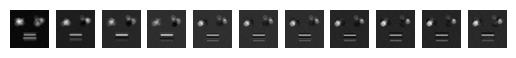

In [5]:
n_components = 10

progressive_face = pca.mean_.copy()
snapshots = [progressive_face.copy()]

for i in range(n_components):
    progressive_face += (face_pca[1][i]*pca.components_[i])
    snapshots.append(progressive_face.copy())
fig,axes = plt.subplots(1,11)

for i, snapshot in enumerate(snapshots):
    reconstructed_face = snapshot.reshape(64,64)
    axes[i].axis('off')
    axes[i].imshow(reconstructed_face, cmap='gray')


In [6]:
print(face_pca[0])

[-2.67753933e+00 -1.05742050e+00 -4.53353173e+00  1.60753721e+00
 -2.76312907e+00 -6.20953781e-01 -8.33500917e-01  2.14229792e+00
  1.47965646e+00  2.74495085e+00 -3.13243635e-01 -4.88679931e-01
  1.23294729e+00 -1.90856181e+00  1.46022248e-01  9.87620297e-01
  6.48052199e-02 -1.42882606e+00 -3.07406715e-01  1.50031897e-15]


In [7]:
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
print(lfw_people.images.shape)
X = lfw_people.data #already flattened
y = lfw_people.target
print(X.shape)
n_components = 150
pca = PCA(n_components=n_components)
X_pca=pca.fit_transform(X)
print(X_pca.shape)

fig, axes = plt.subplots(4,5)
pos = axes.flatten()
for i in range(20):
    eigenface = pca.components_[i]
    reshaped_face = eigenface.reshape(50,37)
    pos[i].axis('off')
    pos[i].imshow(reshaped_face, cmap='RdBu')





(1288, 50, 37)
(1288, 1850)


KeyboardInterrupt: 

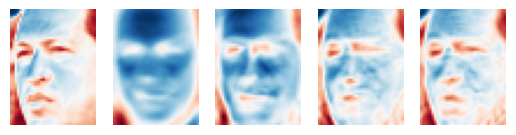

In [ ]:
test_face = X[0].reshape(50,37)
component_list = [10, 50, 100, 150]
faces = [test_face.copy()]

for component in component_list:
    pca = PCA(n_components=component)
    X_pca = pca.fit_transform(X)
    reconstructed_face = pca.inverse_transform(X_pca[0:1])[0].reshape(50,37)
    faces.append(reconstructed_face)
fig, axes = plt.subplots(1,5)
for i, face in enumerate(faces):
    axes[i].axis('off')
    axes[i].imshow(face, cmap='RdBu')


Max cumulative variance: 0.9431416988372803
Does it ever reach 0.95? False
Sum of all explained variance: 0.9431419968605042


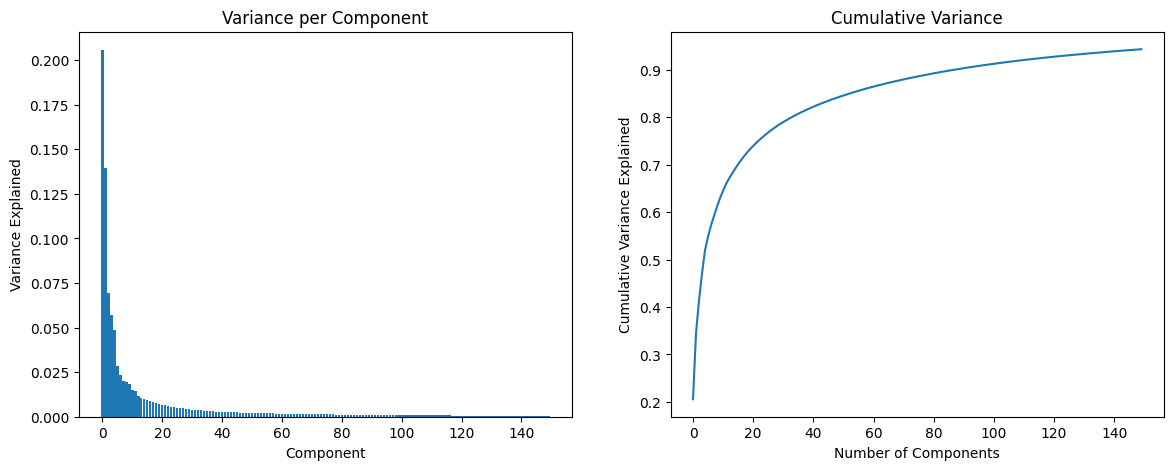

In [ ]:
x_values = np.arange(150)
y_bar = pca.explained_variance_ratio_
y_line = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

#left plot (bar)
axes[0].bar(x_values, y_bar)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Variance per Component')

# right plot
axes[1].plot(x_values, y_line)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance')


cumulative_var = np.cumsum(pca.explained_variance_ratio_)
n_for_95 = np.argmax(cumulative_var >= .95)
print(f"Max cumulative variance: {cumulative_var.max()}")
print(f"Does it ever reach 0.95? {(cumulative_var >= 0.95).any()}")
print(f"Sum of all explained variance: {pca.explained_variance_ratio_.sum()}")


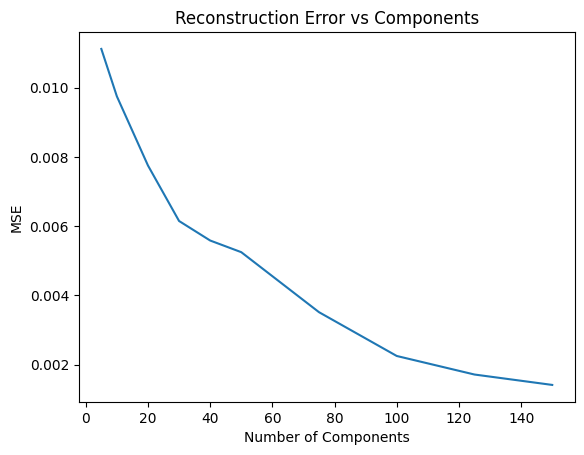

MSE at 50 components: 0.005247494671493769
MSE at 100 components: 0.002248814096674323
MSE at 150 components: 0.001412660232745111


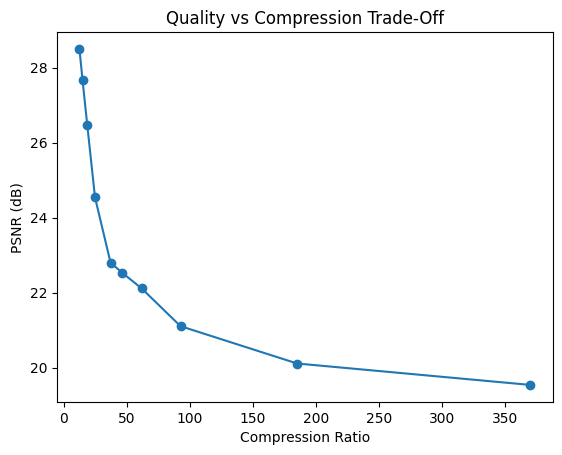

PSNR at 50 components: 22.800479888916016
PSNR at 100 components: 26.480464935302734
PSNR at 150 components: 28.499622344970703


In [ ]:
component_list = [5, 10, 20, 30, 40, 50, 75, 100, 125, 150]
test_face = X[0]
errors = []

for n_comp in component_list:
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X)
    reconstructed_face = pca.inverse_transform(X_pca[0:1])[0]
    mse = np.mean((test_face-reconstructed_face)**2)
    errors.append(mse)

x_values = component_list
y_values = errors
plt.plot(x_values, y_values)
plt.xlabel('Number of Components')
plt.ylabel('MSE')
plt.title('Reconstruction Error vs Components')
plt.show()
print(f"MSE at 50 components: {errors[component_list.index(50)]}")
print(f"MSE at 100 components: {errors[component_list.index(100)]}")
print(f"MSE at 150 components: {errors[component_list.index(150)]}")

psnr_values = []
compression_ratios = []

for n_comp in component_list:
    pca=PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X)
    reconstructed_face = pca.inverse_transform(X_pca[0:1])[0]
    mse = np.mean((test_face-reconstructed_face)**2)
    psnr = (10 * np.log10(1**2 / mse))
    psnr_values.append(psnr)
    compression = 1850/n_comp
    compression_ratios.append(compression)

plt.plot(compression_ratios, psnr_values, marker='o')
plt.xlabel('Compression Ratio')
plt.ylabel('PSNR (dB)')
plt.title('Quality vs Compression Trade-Off')
plt.show()

print(f"PSNR at 50 components: {psnr_values[component_list.index(50)]}")
print(f"PSNR at 100 components: {psnr_values[component_list.index(100)]}")
print(f"PSNR at 150 components: {psnr_values[component_list.index(150)]}")
    

Query face: 100
Most similar face: 304
Distance: 4.431412220001221
Query person: George W Bush
Most similar person: George W Bush


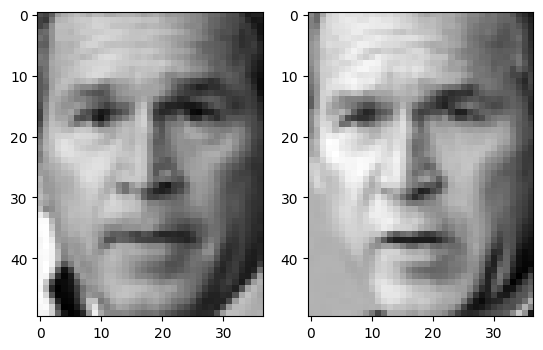

In [ ]:
face_recognition = PCA(n_components=50)
recog_X = face_recognition.fit_transform(X)
query_idx = 100
query_face_pca = recog_X[query_idx]
distances = np.linalg.norm(recog_X - query_face_pca, axis=1)
distances[query_idx] = np.inf
most_similar_idx = distances.argmin()

print(f"Query face: {query_idx}")
print(f"Most similar face: {most_similar_idx}")
print(f"Distance: {distances[most_similar_idx]}")

fig, axes = plt.subplots(1,2)
axes[0].imshow(lfw_people.images[query_idx], cmap='gray')
axes[1].imshow(lfw_people.images[most_similar_idx], cmap='gray')

print(f"Query person: {lfw_people.target_names[lfw_people.target[query_idx]]}")
print(f"Most similar person: {lfw_people.target_names[lfw_people.target[most_similar_idx]]}")


(427, 1920)
(427, 640) (427, 640) (427, 640)


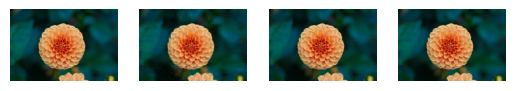

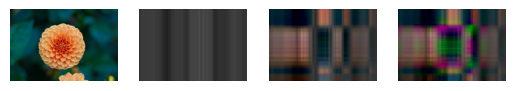

In [18]:
def load_sample_image_rgb() -> np.ndarray:
    img = load_sample_image('flower.jpg')
    return img

def prepare_rgb_concatenated(image: np.ndarray):
    """
    Prepare RGB image for PCA with concatenated channels.

    Args:
        image: (height, width, 3) np.ndarray
    
    returns:
    np.ndarray (height, 3wi*width)
    """
    reshaped = image.reshape(image.shape[0],-1)
    return reshaped


    

def prepare_rgb_per_channel(image: np.ndarray):
    """
    Prepare RGB image for PCA with separate channels.

    Args:
        image: (height, width, 3) array

    Returns:
        Tuple: ([height, width], [height, width], [height, width])
    """
    r = image[:,:,0]
    g = image[:,:,1]
    b = image[:,:,2]
    return (r,g,b)
    
img = load_sample_image_rgb()
concat = prepare_rgb_concatenated(img)
print(concat.shape)
r,g,b = prepare_rgb_per_channel(img)
print(r.shape, g.shape, b.shape)
concat_n_components = [30,60,90]
pc_n_components = [10, 20, 30]
concat_reconstructions = [img]
pc_reconstructions = [img]

concat_pca = PCA(n_components=30)
concat_transformed = concat_pca.fit_transform(concat)

for i in range(3):
    concat_data = prepare_rgb_concatenated(img)
    concat_pca = PCA(n_components=concat_n_components[i])
    concat_transformed = concat_pca.fit_transform(concat_data)
    reconstructed = concat_pca.inverse_transform(concat_transformed)
    reshaped_img = reconstructed.reshape(img.shape[0], img.shape[1], 3)
    reshaped_img = np.clip(reshaped_img, 0, 255)
    reshaped_img = reshaped_img.astype(np.uint8)
    concat_reconstructions.append(reshaped_img)

fig, axes = plt.subplots(1,4)
for i, img in enumerate(concat_reconstructions):
    axes[i].axis('off')
    axes[i].imshow(img)

for i in range(3):
    r,g,b = prepare_rgb_per_channel(img)
    rgb_pca = PCA(n_components=i)
    r_fitted = rgb_pca.fit_transform(r)
    g_fitted = rgb_pca.fit_transform(g)
    b_fitted = rgb_pca.fit_transform(b)
    r_reconstructed = rgb_pca.inverse_transform(r_fitted)
    g_reconstructed = rgb_pca.inverse_transform(g_fitted)
    b_reconstructed = rgb_pca.inverse_transform(b_fitted)
    rgb_reshaped = np.stack((r_reconstructed, g_reconstructed, b_reconstructed), axis=2)
    rgb_reshaped = np.clip(rgb_reshaped, 0, 255)
    rgb_reshaped = rgb_reshaped.astype(np.uint8)

    pc_reconstructions.append(rgb_reshaped)

fig,axes = plt.subplots(1,4)
for i, img in enumerate(pc_reconstructions):
    axes[i].axis('off')
    axes[i].imshow(img)
   

    

In [20]:
class SVD:
    
    def __init__(self, n_components: int):
        """
        initialize svd object
        """
        self.n_components = n_components
        self.components_ = None # store V^T, shape (n_components, n_features)
        self.singular_values_ = None
        self.explained_variance_ = None
        self.mean_ = None
    
    def fit(self, X: np.ndarray):
        
        self.mean_ = X.mean(axis=0)
        centered_X = X - self.mean_
        At = centered_X @ centered_X.T
        eigenvalues, eigenvectors = np.linalg.eigh(At)
        idx = eigenvalues.argsort()[::-1] #indices to sort descending
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:,idx]
        #keep only top n_components
        eigenvalues = eigenvalues[:self.n_components] # transpose to match expected shape.
        eigenvectors = eigenvectors[:, :self.n_components]
        self.singular_values_ = np.sqrt(np.maximum(0, eigenvalues))
        self.components_ = (1/self.singular_values_)[:, None] * (eigenvectors.T @ centered_X)
        n_samples = X.shape[0]
        self.explained_variance_ = (self.singular_values_**2) / (n_samples - 1)

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X_centered = X - self.mean_
        return X_centered @ self.components_.T * (1/self.singular_values_)

    def inverse_transform(self, X_transformed: np.ndarray) -> np.ndarray:

        X_centered = (X_transformed * self.singular_values_) @ self.components_
        return X_centered + self.mean_
    
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        
        return self.fit(X).transform(X)


         


In [24]:
import time
image = load_sample_image_rgb()
svd = SVD(30)
pca = PCA(n_components=30)
concat = prepare_rgb_concatenated(image)
start_svd = time.time()
svd_ft = svd.fit_transform(concat)
svd_reconstructed = svd.inverse_transform(svd_ft)
end_svd = time.time()
start_pca = time.time()
pca_ft = pca.fit_transform(concat)
pca_reconstructed = pca.inverse_transform(pca_ft)
end_pca = time.time()

print(f"PCA: {end_pca - start_pca:.4f}s")
print(f"SVD: {end_svd - start_svd:.4f}s")

difference = np.abs(pca_reconstructed - svd_reconstructed)
print(f"Max difference: {difference.max()}")
print(f"Mean difference: {difference.mean()}")

PCA: 0.4106s
SVD: 0.0257s
Max difference: 1.7415402453480056e-11
Mean difference: 1.8263877188525841e-13
